In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

INPUT_FILE = "data/DB_final.csv"
OUTPUT_FILE = "data/DB_final_with_BERT.csv"
MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 8  
MAX_LENGTH = 512  
CHUNK_OVERLAP = 50  

df = pd.read_csv(INPUT_FILE)
texts = df['Text'].tolist()


print(f"\nLoading BERT model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Freeze model weights
for param in model.parameters():
    param.requires_grad = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"Model loaded on device: {device}")


def chunk_text_by_tokens(text, tokenizer, max_length=MAX_LENGTH, overlap=CHUNK_OVERLAP):
    """
    Split long text into overlapping chunks based on token count.
    Ensures chunks never exceed max_length tokens.
    Returns list of token tensors.
    """
    # Tokenize entire text without truncation
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=False,
        truncation=False,
        return_tensors=None
    )
    token_ids = encoded['input_ids']
    
    # If text fits in one chunk, return it
    if len(token_ids) <= max_length - 2: # -2 because of special tokens
        inputs = tokenizer.encode_plus(
            text,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return [inputs]
    
    # Split tokens into overlapping chunks
    chunks = []
    chunk_size = max_length - 2
    stride = chunk_size - overlap
    
    for i in range(0, len(token_ids), stride):
        chunk_ids = token_ids[i:i + chunk_size]
        
        # Convert back to text
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)
        
        chunk_input = tokenizer.encode_plus(
            chunk_text,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        chunks.append(chunk_input)
        
        if i + chunk_size >= len(token_ids):
            break
    
    return chunks if chunks else [tokenizer.encode_plus(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )]

def get_bert_embeddings(text_list, batch_size=BATCH_SIZE):
    """
    Extract BERT embeddings for long texts using token-based chunking.
    
    Args:
        text_list: List of text strings (can be very long)
        batch_size: Number of chunks to process at once    
    Returns:
        numpy array of shape (n_texts, 768) containing embeddings
    """
    all_embeddings = []
    
    for text in tqdm(text_list, desc="Extracting BERT Embeddings"):
        try:
            chunks = chunk_text_by_tokens(str(text), tokenizer)
            chunk_embeddings = []
            
            for i in range(0, len(chunks), batch_size):
                batch_chunks = chunks[i:i+batch_size]
                
                # Stack inputs safely
                input_ids = torch.cat([c['input_ids'] for c in batch_chunks]).to(device)
                attention_mask = torch.cat([c['attention_mask'] for c in batch_chunks]).to(device)
                
                with torch.no_grad():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    cls_embs = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                    chunk_embeddings.append(cls_embs)
            
            all_chunk_embs = np.vstack(chunk_embeddings)
            
            text_embedding = np.mean(all_chunk_embs, axis=0)
            all_embeddings.append(text_embedding)
            
        except Exception as e:
            print(f"Error processing text: {str(e)[:100]}") 
            all_embeddings.append(np.zeros(768)) # 768 is BERT hidden size
    
    return np.array(all_embeddings)

print(f"\n{'='*60}")
print("Starting BERT embedding extraction...")
print(f"{'='*60}")
bert_embeddings = get_bert_embeddings(texts)

bert_columns = [f'bert_{i}' for i in range(bert_embeddings.shape[1])]
df_bert = pd.DataFrame(bert_embeddings, columns=bert_columns)
df_combined = pd.concat([df.reset_index(drop=True), df_bert], axis=1)

print(f"\nCombined dataset shape: {df_combined.shape}")
print(f"Saving combined dataset to {OUTPUT_FILE}...")
df_combined.to_csv(OUTPUT_FILE, index=False)
print(f"Successfully saved {len(df_combined):,} rows to {OUTPUT_FILE}")

del bert_embeddings, df_bert
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ BERT feature extraction complete!")


Loading BERT model: bert-base-uncased
Model loaded on device: cuda
Strategy: Chunking long texts with mean pooling

Starting BERT embedding extraction...


Extracting BERT Embeddings: 100%|██████████| 51181/51181 [31:36<00:00, 26.99it/s] 



Combined dataset shape: (51181, 787)
Saving combined dataset to data/DB_final_with_BERT.csv...
Successfully saved 51,181 rows to data/DB_final_with_BERT.csv
✓ BERT feature extraction complete!


Classes: ['GPT_4-o' 'Human_story' 'accounts/yi-01-ai/models/yi-large' 'gemma-2-9b'
 'llama-8B' 'mistral-7B' 'qwen-2-72B']
Train set: 40944 samples
Test set: 10237 samples

Training Writer Classification Model...
[0]	validation_0-mlogloss:1.88029	validation_0-merror:0.42180
[100]	validation_0-mlogloss:0.71420	validation_0-merror:0.23571
[200]	validation_0-mlogloss:0.58246	validation_0-merror:0.20768
[300]	validation_0-mlogloss:0.53427	validation_0-merror:0.19576
[400]	validation_0-mlogloss:0.51065	validation_0-merror:0.19156
[499]	validation_0-mlogloss:0.49887	validation_0-merror:0.18677

Writer Classification Accuracy: 0.8139

Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.93      0.94      0.94      1465
                      Human_story       0.99      0.99      0.99      1459
accounts/yi-01-ai/models/yi-large       0.71      0.78      0.75      1464
                       gemma-2-9b       0

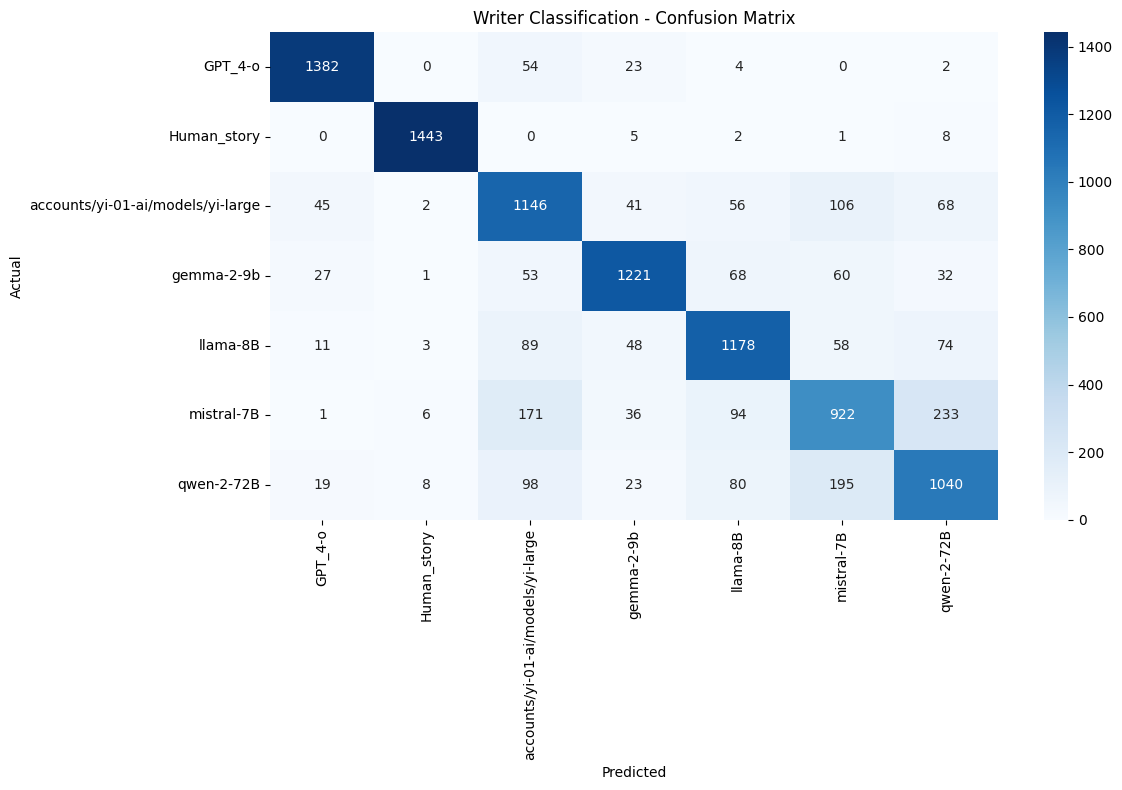


Top 20 Important Features:
           Feature  Importance
653       bert_637    0.051264
225       bert_209    0.016181
332       bert_316    0.015234
566       bert_550    0.013706
462       bert_446    0.011762
318       bert_302    0.011730
10      burstiness    0.010514
203       bert_187    0.010013
14   semantic_mean    0.010007
160       bert_144    0.008572
280       bert_264    0.008129
461       bert_445    0.008081
436       bert_420    0.007326
776       bert_760    0.006828
49         bert_33    0.006309
158       bert_142    0.006015
100        bert_84    0.005771
324       bert_308    0.005609
525       bert_509    0.005552
736       bert_720    0.005505


/tmp/ipykernel_75255/708447130.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


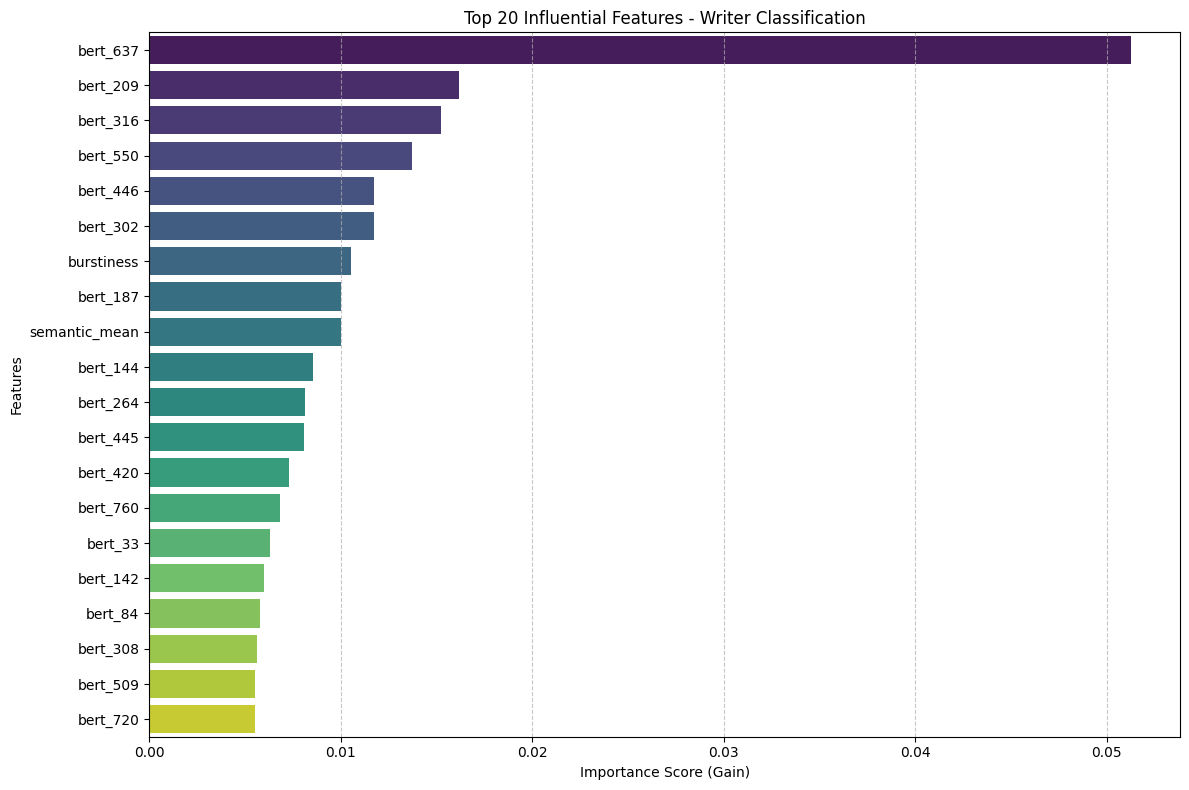

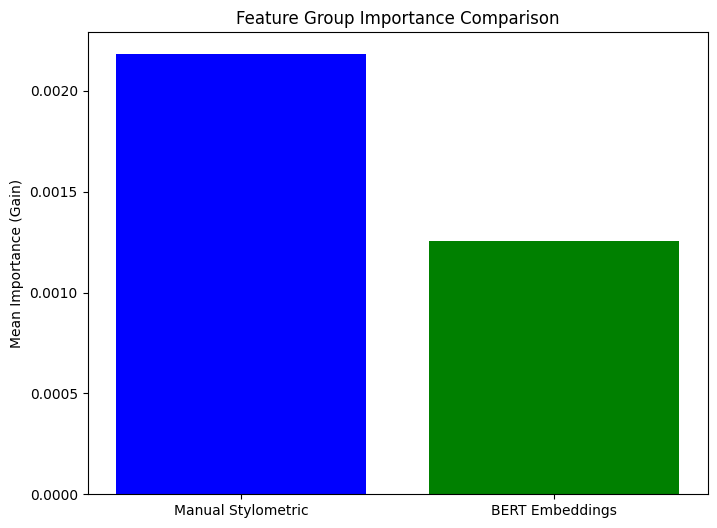


Model saved to 'models/xgb_classifier_writer_with_BERT.pkl'


In [ ]:
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
import joblib


df=pd.read_csv(OUTPUT_FILE)

X = df.drop(columns=['Text', 'is_AI',"Writer"])
y = df['Writer']

X = X.apply(pd.to_numeric, errors='coerce')

le = LabelEncoder()                                        
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_encoded
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples\n")

xgb_classifier = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric=['mlogloss', 'merror'],
    n_estimators=500,
    early_stopping_rounds=50,
    learning_rate=0.05,
    max_depth=8,
    random_state=999,
    verbosity=0
)

print("Training Writer Classification Model...")
xgb_classifier.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=100
)

# Evaluate
y_pred = xgb_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*60}")
print(f"Writer Classification Accuracy: {accuracy:.4f}")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Writer Classification - Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance
importances = xgb_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Influential Features - Writer Classification')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


importances = xgb_classifier.feature_importances_
manual_imp = np.mean(importances[:len(X.columns) - 768])
bert_imp = np.mean(importances[len(X.columns) - 768:])

plt.figure(figsize=(8, 6))
plt.bar(['Manual Stylometric', 'BERT Embeddings'], [manual_imp, bert_imp], color=['blue', 'green'])
plt.ylabel('Mean Importance (Gain)')
plt.title('Feature Group Importance Comparison')
plt.show()

# Save model
joblib.dump(xgb_classifier, 'models/xgb_classifier_with_BERT.pkl')
print("\nModel saved to 'models/xgb_classifier_with_BERT.pkl'")


Features shape: (51181, 784)
Target distribution:
is_AI
1    43886
0     7295
Name: count, dtype: int64

Train set: 40944 samples
Test set: 10237 samples
Train distribution: {1: 35108, 0: 5836}
Test distribution: {1: 8778, 0: 1459}

[0]	validation_0-logloss:0.36957	validation_0-auc:0.96757
[100]	validation_0-logloss:0.02366	validation_0-auc:0.99950
[200]	validation_0-logloss:0.01663	validation_0-auc:0.99973
[300]	validation_0-logloss:0.01500	validation_0-auc:0.99979
[400]	validation_0-logloss:0.01409	validation_0-auc:0.99982
[499]	validation_0-logloss:0.01368	validation_0-auc:0.99983

AI Detection Accuracy: 0.9963

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      1459
          AI       1.00      1.00      1.00      8778

    accuracy                           1.00     10237
   macro avg       1.00      0.99      0.99     10237
weighted avg       1.00      1.00      1.00     10237



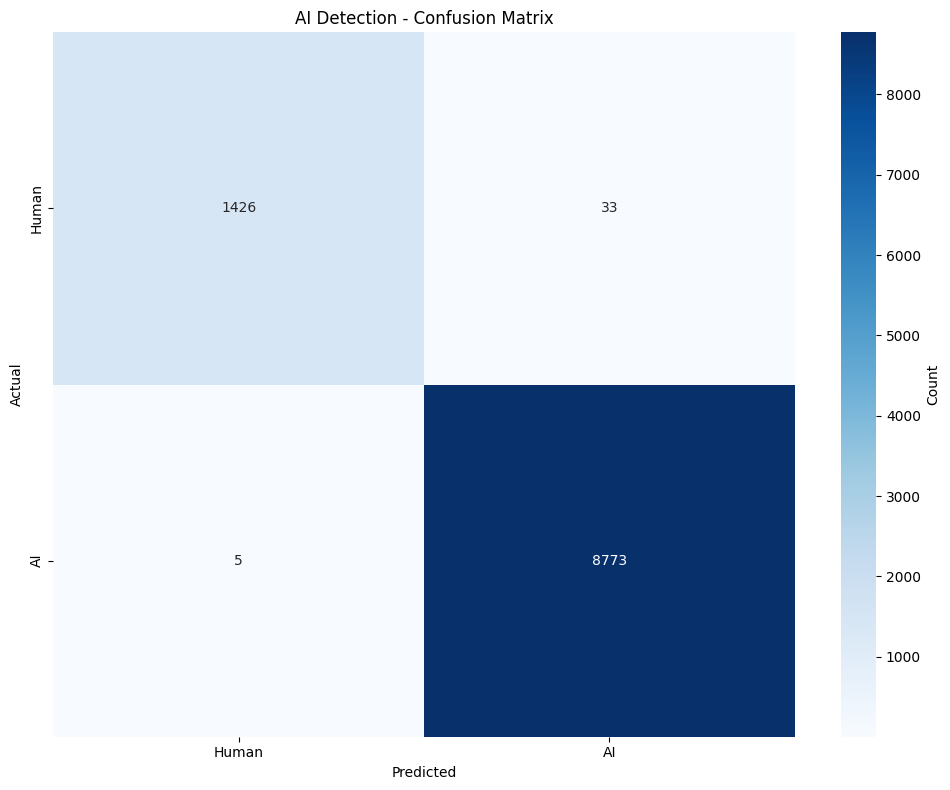


Top 20 Important Features:
      Feature  Importance
653  bert_637    0.330339
225  bert_209    0.068552
462  bert_446    0.036114
39    bert_23    0.021053
461  bert_445    0.018468
100   bert_84    0.017484
135  bert_119    0.012455
161  bert_145    0.010475
324  bert_308    0.010425
139  bert_123    0.008275
583  bert_567    0.006702
649  bert_633    0.006550
479  bert_463    0.005966
545  bert_529    0.005652
176  bert_160    0.004825
56    bert_40    0.004616
221  bert_205    0.004559
718  bert_702    0.004482
642  bert_626    0.004412
603  bert_587    0.004061


/tmp/ipykernel_75255/1516186493.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


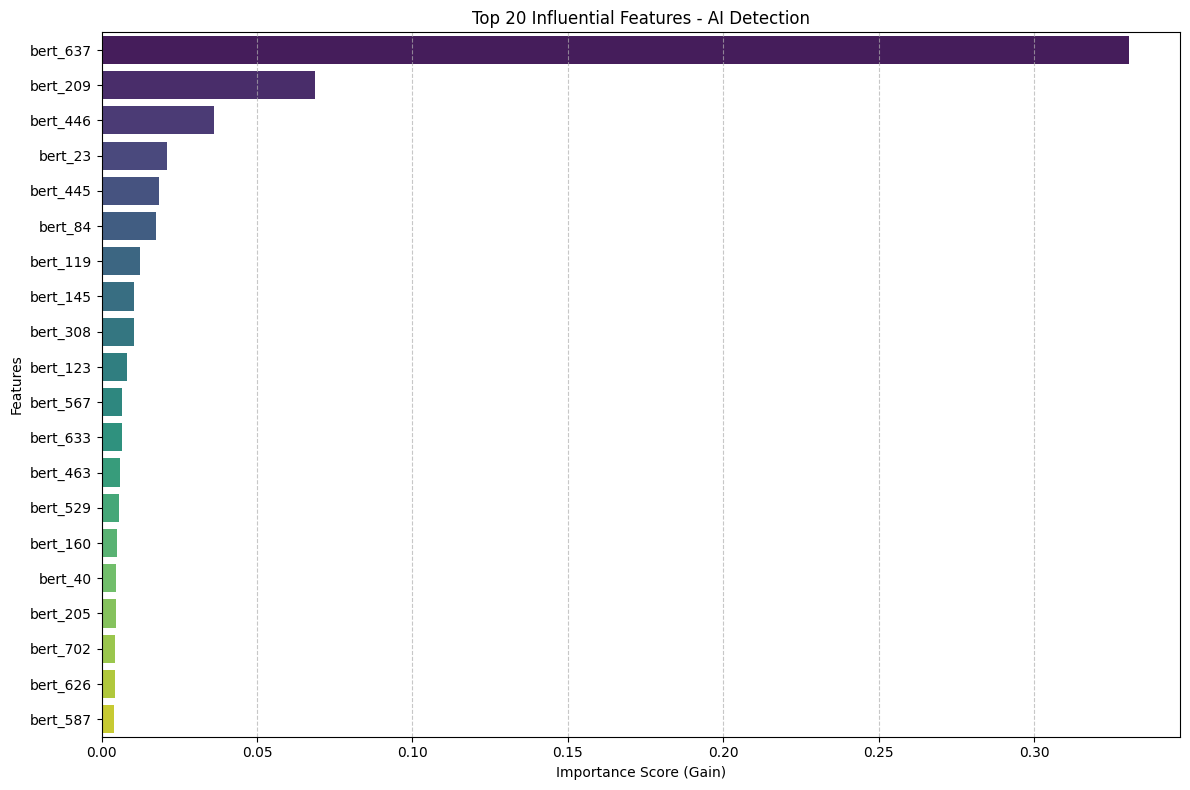

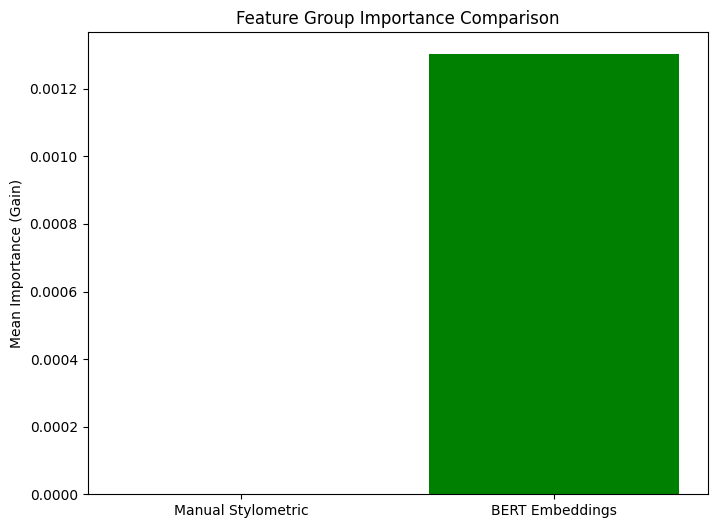


✓ Model saved to 'models/xgb_is_ai_model_with_BERT.pkl'


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib


df=pd.read_csv(OUTPUT_FILE)


X = df.drop(columns=['Text', 'Writer',"is_AI"], errors='ignore')
y = df['is_AI']
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}\n")

# Check for missing values in X and y
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Dropping rows with missing values...")
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]
    print(f"Dataset after cleaning: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=999, 
    stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train distribution: {y_train.value_counts().to_dict()}")
print(f"Test distribution: {y_test.value_counts().to_dict()}\n")

xgb_is_ai = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric=['logloss', 'auc'],
    n_estimators=500,
    early_stopping_rounds=50,
    learning_rate=0.05,
    max_depth=8,
    random_state=999,
    verbosity=0
)

xgb_is_ai.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=100
)

# Evaluate
y_pred = xgb_is_ai.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*60}")
print(f"AI Detection Accuracy: {accuracy:.4f}")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AI Detection - Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance
importances = xgb_is_ai.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Influential Features - AI Detection')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


importances = xgb_is_ai.feature_importances_
manual_imp = np.mean(importances[:len(X.columns) - 768])
bert_imp = np.mean(importances[len(X.columns) - 768:])

plt.figure(figsize=(8, 6))
plt.bar(['Manual Stylometric', 'BERT Embeddings'], [manual_imp, bert_imp], color=['blue', 'green'])
plt.ylabel('Mean Importance (Gain)')
plt.title('Feature Group Importance Comparison')
plt.show()

# Save model
joblib.dump(xgb_is_ai, 'models/xgb_is_ai_with_BERT.pkl')
print("\n✓ Model saved to 'models/xgb_is_ai_with_BERT.pkl'")